### Amsterdam houses

https://www.kaggle.com/

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("HousingPrices-Amsterdam-August-2021.csv")
df.head(5)

,Unnamed: 0,Address,Zip,Price,Area,Room,Lon,Lat
0,1,"Blasiusstraat 8 2, Amsterdam",1091 CR,685000.0,64,3,4.907736,52.356157
1,2,"Kromme Leimuidenstraat 13 H, Amsterdam",1059 EL,475000.0,60,3,4.850476,52.348586
2,3,"Zaaiersweg 11 A, Amsterdam",1097 SM,850000.0,109,4,4.944774,52.343782
3,4,"Tenerifestraat 40, Amsterdam",1060 TH,580000.0,128,6,4.789928,52.343712
4,5,"Winterjanpad 21, Amsterdam",1036 KN,720000.0,138,5,4.902503,52.410538


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 924 entries, 0 to 923
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  924 non-null    int64  
 1   Address     924 non-null    object 
 2   Zip         924 non-null    object 
 3   Price       920 non-null    float64
 4   Area        924 non-null    int64  
 5   Room        924 non-null    int64  
 6   Lon         924 non-null    float64
 7   Lat         924 non-null    float64
dtypes: float64(3), int64(3), object(2)
memory usage: 57.9+ KB


In [4]:
df.describe()

,Unnamed: 0,Price,Area,Room,Lon,Lat
count,924.000000,9.200000e+02,924.000000,924.000000,924.000000,924.000000
mean,462.500000,6.220654e+05,95.952381,3.571429,4.888605,52.363326
std,266.880123,5.389942e+05,57.447436,1.592332,0.053140,0.024028
min,1.000000,1.750000e+05,21.000000,1.000000,4.644819,52.291519
25%,231.750000,3.500000e+05,60.750000,3.000000,4.855834,52.352077
50%,462.500000,4.670000e+05,83.000000,3.000000,4.886818,52.364631
75%,693.250000,7.000000e+05,113.000000,4.000000,4.922337,52.377598
max,924.000000,5.950000e+06,623.000000,14.000000,5.029122,52.423805


array([[<Axes: title={'center': 'Unnamed: 0'}>,
        <Axes: title={'center': 'Price'}>],
       [<Axes: title={'center': 'Area'}>,
        <Axes: title={'center': 'Room'}>],
       [<Axes: title={'center': 'Lon'}>, <Axes: title={'center': 'Lat'}>]],
      dtype=object)

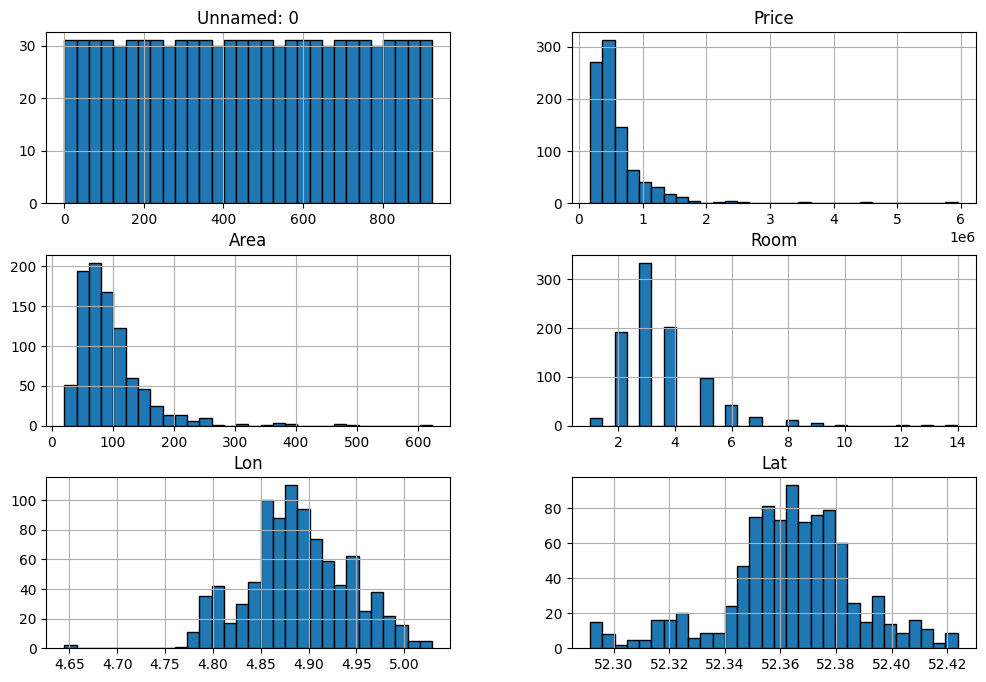

In [5]:
df.hist(edgecolor='black', bins=30, figsize=(12,8))

In [6]:
#caso 1 - elimino i dati mancanti (colonna prezzo)
df1= df.dropna( subset=["Price"] )
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 920 entries, 0 to 923
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  920 non-null    int64  
 1   Address     920 non-null    object 
 2   Zip         920 non-null    object 
 3   Price       920 non-null    float64
 4   Area        920 non-null    int64  
 5   Room        920 non-null    int64  
 6   Lon         920 non-null    float64
 7   Lat         920 non-null    float64
dtypes: float64(3), int64(3), object(2)
memory usage: 64.7+ KB


In [7]:
#caso 2 - inserisco il valor medio
valmedio = df["Price"].mean()
print("prezzo medio:", valmedio)

#creo una copia del df
df2 = df.copy()
df2["Price"] = df2["Price"].fillna(valmedio)
df2.info()


prezzo medio: 622065.4195652173
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 924 entries, 0 to 923
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  924 non-null    int64  
 1   Address     924 non-null    object 
 2   Zip         924 non-null    object 
 3   Price       924 non-null    float64
 4   Area        924 non-null    int64  
 5   Room        924 non-null    int64  
 6   Lon         924 non-null    float64
 7   Lat         924 non-null    float64
dtypes: float64(3), int64(3), object(2)
memory usage: 57.9+ KB


In [8]:
#rinomino la prima colonna
df3 = df1.rename(columns={"Unnamed: 0":"houseid"}  )
df3.head()

,houseid,Address,Zip,Price,Area,Room,Lon,Lat
0,1,"Blasiusstraat 8 2, Amsterdam",1091 CR,685000.0,64,3,4.907736,52.356157
1,2,"Kromme Leimuidenstraat 13 H, Amsterdam",1059 EL,475000.0,60,3,4.850476,52.348586
2,3,"Zaaiersweg 11 A, Amsterdam",1097 SM,850000.0,109,4,4.944774,52.343782
3,4,"Tenerifestraat 40, Amsterdam",1060 TH,580000.0,128,6,4.789928,52.343712
4,5,"Winterjanpad 21, Amsterdam",1036 KN,720000.0,138,5,4.902503,52.410538


<Axes: ylabel='Frequency'>

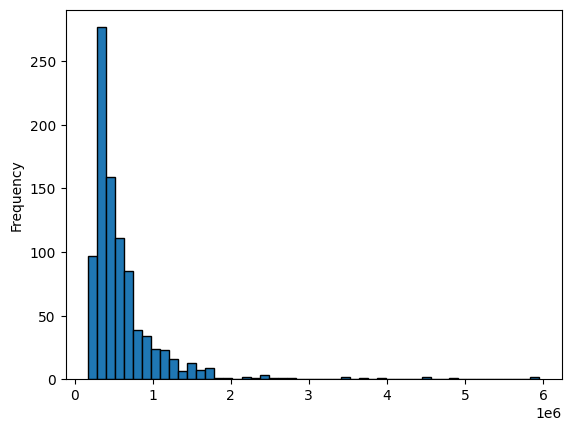

In [9]:
#creo un istogramma dei prezzi
import matplotlib as plt
df3["Price"].plot(kind="hist", bins=50, edgecolor="black")

<Axes: xlabel='Area', ylabel='Price'>

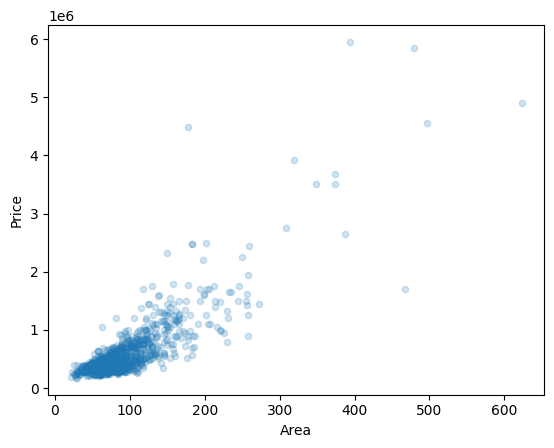

In [10]:
df3.plot(kind="scatter", x="Area", y="Price", alpha=0.2)

<Axes: xlabel='Area', ylabel='Price'>

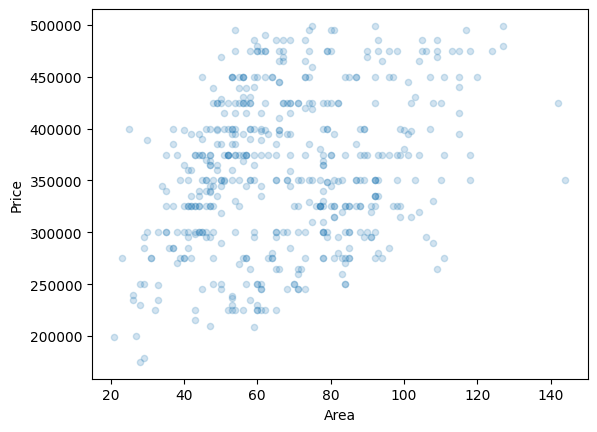

In [11]:
#per vedere una zona in particolare...
df4 = df3[ df3["Price"] < 500000 ]
df4.plot(kind="scatter", x="Area", y="Price", alpha=0.2) 

<Axes: xlabel='Area', ylabel='Price'>

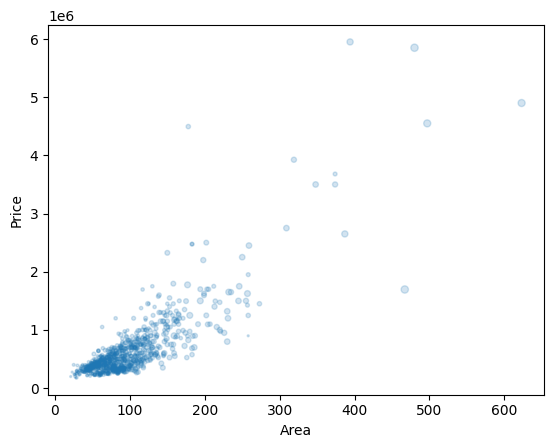

In [12]:
df3.plot(kind="scatter", x="Area", y="Price", s=df3["Room"]*2, alpha=0.2)

In [13]:
#creo una nuova colonna con un campo calcolato
df3["prezzo_mq"] = df3["Price"]/df3["Area"]
df3.head()

,houseid,Address,Zip,Price,Area,Room,Lon,Lat,prezzo_mq
0,1,"Blasiusstraat 8 2, Amsterdam",1091 CR,685000.0,64,3,4.907736,52.356157,10703.125000
1,2,"Kromme Leimuidenstraat 13 H, Amsterdam",1059 EL,475000.0,60,3,4.850476,52.348586,7916.666667
2,3,"Zaaiersweg 11 A, Amsterdam",1097 SM,850000.0,109,4,4.944774,52.343782,7798.165138
3,4,"Tenerifestraat 40, Amsterdam",1060 TH,580000.0,128,6,4.789928,52.343712,4531.250000
4,5,"Winterjanpad 21, Amsterdam",1036 KN,720000.0,138,5,4.902503,52.410538,5217.391304


<Axes: xlabel='Area', ylabel='Price'>

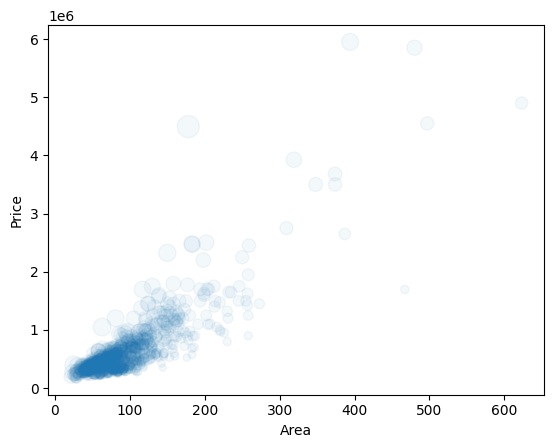

In [14]:
df3.plot(kind="scatter", x="Area", y="Price", s=df3["prezzo_mq"]/100, alpha=0.05)

<Axes: xlabel='Lat', ylabel='Lon'>

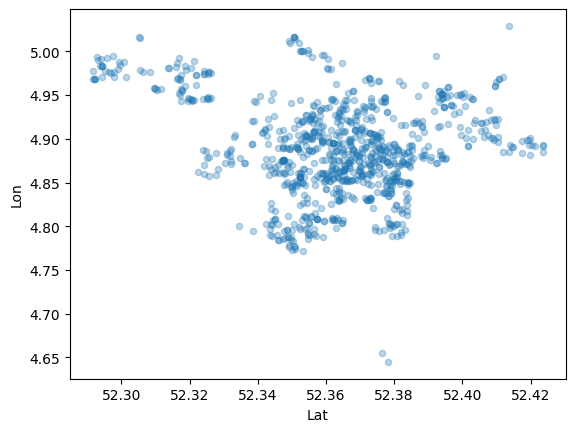

In [15]:
df3.plot(kind="scatter", x="Lat", y="Lon", alpha=0.3)

In [16]:
# %pip install folium
import folium

In [17]:
mappa = folium.Map(location=[52.36, 4.85], zoom_start=10, width="70%", height="60%")
for index, row in df3.iterrows():
    folium.CircleMarker(
        location=[row['Lat'], row['Lon']],
        radius=row["Price"]/100000,
        color="blue",
        fill=True,
        fill_color="blue",
        fill_opacity=0.2,
        tooltip=row["Price"]
    ).add_to(mappa)
mappa